1. Exploratory Data Analysis: Include a small number of relevant summaries or plots and focus on insights that influenced your modeling. 
2. Data Preparation: Show the preprocessing steps used for modeling. 
3. Feature Engineering or Feature Selection: Evaluate whether feature engineering or feature selection improved or simplified your model. 
4. Modeling and Evaluation: Build and evaluate at least two models that differ in a meaningful way. Models should be tuned beyond default values. Use an appropriate validation strategy and evaluation metric. 
5. Ensembling: Evaluate whether combining models improves performance. The models you combine should differ in a meaningful way. 
6. Results Summary: Summarize the models you evaluated and identify your final model. Include model name, key preprocessing or features, validation method, evaluation metric, validation score, and a brief reason for your final choice. Present this in a clear, structured format. 
7. Final Model and Predictions: Train your final model and generate predictions for the test set. Do not use the test set for tuning.

In [ ]:
import pandas as pd
import numpy as np

# =========================
# importing visualization libraries
# =========================
import matplotlib.pyplot as plt
import seaborn as sns
import sweetviz as sv

# =========================
# importing libraries for modeling and preprocessing
# =========================
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, PowerTransformer

# =========================
# import libraries for models
# =========================
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
import lightgbm as lgb

# =========================
# importing libraries for metric evaluation
# =========================
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer
)

# =========================
# libraries for tuning
# =========================
import optuna


# Preprocessing features

In [67]:
df_train = pd.read_csv(r'c:\Users\prchandr\Downloads\midterm_train.csv')
df_test = pd.read_csv(r'c:\Users\prchandr\Downloads\midterm_test.csv')
df_train.head()

,id,customer_age,occupation_type,relationship_status,education_background,has_credit_issue,mortgage_status,personal_loan_status,last_contact_month,day_of_week,...,prior_contact_count,prior_outcome_status,economic_activity_change,consumer_price_index,consumer_confidence_index,reference_interest_rate,employment_level_index,accepted_offer,is_repeat_customer,recent_contact_flag
0,12556,28,services,married,high.school,no,yes,no,jul,tue,...,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,0,0,0
1,35451,27,admin.,married,university.degree,no,yes,yes,jul,fri,...,0,nonexistent,1.4,93.918,-42.7,4.959,5228.1,0,0,0
2,30592,43,self-employed,married,high.school,unknown,yes,no,apr,wed,...,0,nonexistent,-1.8,93.075,-47.1,1.498,5099.1,0,0,0
3,17914,43,admin.,single,university.degree,no,yes,no,aug,fri,...,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0,0,0
4,3315,41,admin.,married,unknown,no,no,no,sep,wed,...,3,success,-1.1,94.199,-37.5,0.886,4963.6,1,1,1


In [3]:
print(df_train.columns.tolist())

['id', 'customer_age', 'occupation_type', 'relationship_status', 'education_background', 'has_credit_issue', 'mortgage_status', 'personal_loan_status', 'last_contact_month', 'day_of_week', 'contact_time_minutes', 'contact_attempt_count', 'days_since_prior_contact', 'prior_contact_count', 'prior_outcome_status', 'economic_activity_change', 'consumer_price_index', 'consumer_confidence_index', 'reference_interest_rate', 'employment_level_index', 'accepted_offer', 'is_repeat_customer', 'recent_contact_flag']


In [4]:
X = df_train.drop(['accepted_offer'], axis=1)
y = df_train['accepted_offer']

In [5]:
print("Train shape:", df_train.shape)
print("Test shape :", df_test.shape)

Train shape: (32950, 23)
Test shape : (8238, 22)


In [10]:
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object']).columns.tolist()
print("categorical columns:", len(cat_cols))
print("numerical columns:", len(num_cols), "\n")

categorical columns: 9
numerical columns: 13 



C:\Users\prchandr\AppData\Local\Temp\1\ipykernel_26468\349168537.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object']).columns.tolist()


# Exploratory Data Analysis

checking for total nulls

In [14]:
print("Train nulls:", X.isnull().sum().sum())
print("Test nulls:", df_test.isnull().sum().sum())

Train nulls: 0
Test nulls: 0


checking for class imbalance

In [10]:
df_train['accepted_offer'].value_counts(normalize=True)

accepted_offer
0    0.887253
1    0.112747
Name: proportion, dtype: float64

identifying strong categorical features

In [11]:
cat_summary = []

for col in cat_cols:
    grouped = df_train.groupby(col)['accepted_offer'].agg(['count', 'mean'])
    
    max_rate = grouped['mean'].max()
    min_rate = grouped['mean'].min()
    spread = max_rate - min_rate
    min_count = grouped['count'].min()
    
    cat_summary.append({
        'feature': col,
        'max acceptance': max_rate,
        'min acceptance': min_rate,
        'difference between max and min': spread,
        'minimum group size': min_count,
        'number of unique responses': df_train[col].nunique()
    })

cat_summary_df = pd.DataFrame(cat_summary)

cat_summary_df.sort_values(by='difference between max and min', ascending=False)

,feature,max acceptance,min acceptance,difference between max and min,minimum group size,number of unique responses
8,prior_outcome_status,0.636607,0.088605,0.548002,1120,3
6,last_contact_month,0.513761,0.064208,0.449554,145,10
0,occupation_type,0.316832,0.068966,0.247866,262,12
3,has_credit_issue,0.128560,0.000000,0.128560,3,3
2,education_background,0.187500,0.077008,0.110492,16,8
1,relationship_status,0.140144,0.101664,0.038480,68,4
7,day_of_week,0.121573,0.100719,0.020853,6293,5
4,mortgage_status,0.116014,0.103053,0.012961,786,3
5,personal_loan_status,0.113405,0.103053,0.010352,786,3


In [ ]:
# Keeping categorical features with meaningful spread and minimum number of observations 
top_cat_cols = (
    cat_summary_df
    .query("`difference between max and min` >= 0.10 and `minimum group size` >= 50")
    ["feature"]
    .tolist()
)

print("Categorical features with higher association of accepting offer: ", top_cat_cols)

Categorical features with higher association of accepting offer:  ['occupation_type', 'last_contact_month', 'prior_outcome_status']


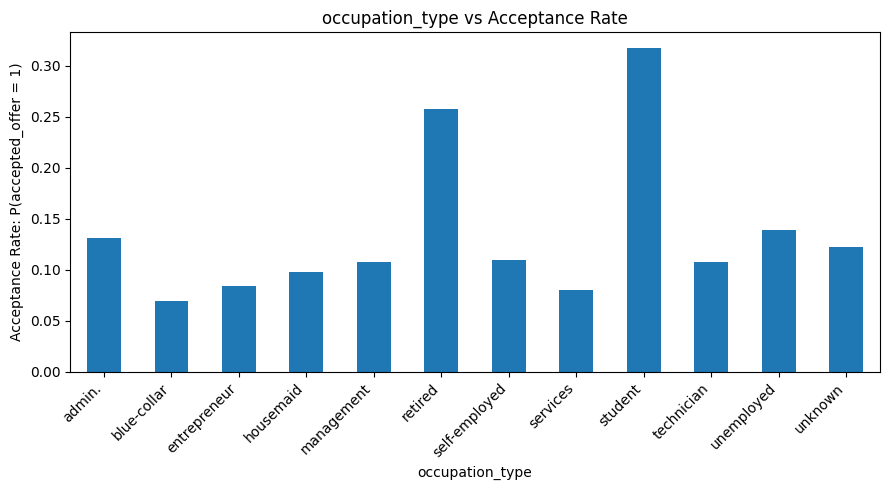

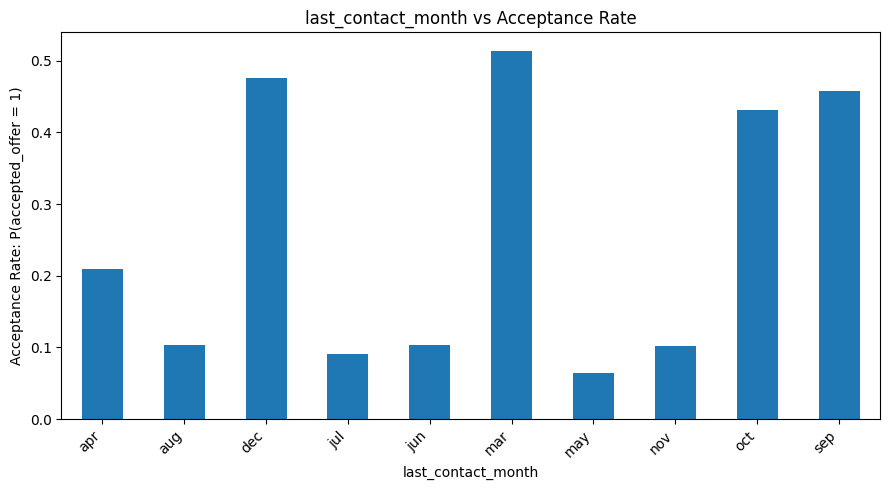

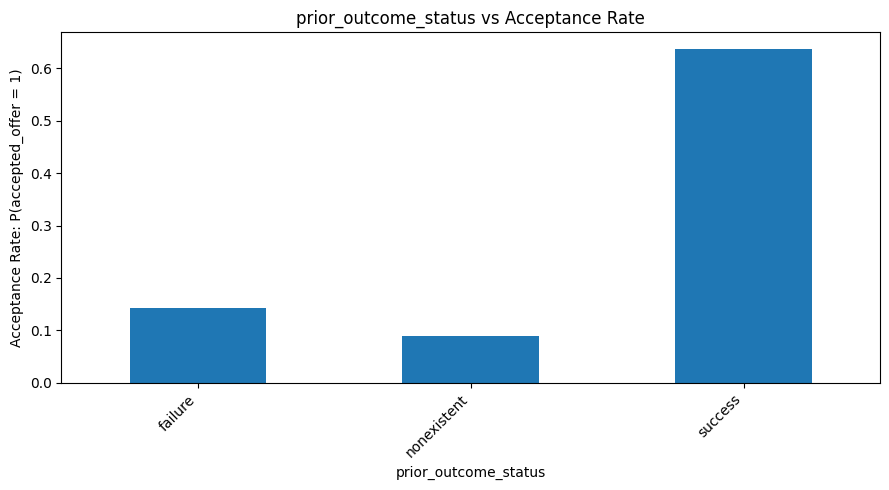

In [13]:
for col in top_cat_cols:
    rate = (
        df_train
        .groupby(col)["accepted_offer"]
        .mean()
    )

    plt.figure(figsize=(9, 5))
    rate.plot(kind="bar")
    plt.title(f"{col} vs Acceptance Rate")
    plt.ylabel("Acceptance Rate: P(accepted_offer = 1)")
    plt.xlabel(col)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

identifying strong numerical categories

In [14]:
num_summary = []

for col in num_cols:
    grouped = df_train.groupby('accepted_offer')[col].agg(['mean', 'median', 'count'])
    
    # Only proceed if both classes exist
    if 0 in grouped.index and 1 in grouped.index:
        mean_diff = abs(grouped.loc[1, 'mean'] - grouped.loc[0, 'mean'])
        median_diff = abs(grouped.loc[1, 'median'] - grouped.loc[0, 'median'])
        
        num_summary.append({
            'feature': col,
            'mean(accepted) - mean(declined)': mean_diff,  # sensitive to outliers and therefore needs a follow-up with median
            'median(accepted) - median(declined)': median_diff
        })

num_summary_df = pd.DataFrame(num_summary)

num_summary_df.sort_values(by='median(accepted) - median(declined)', ascending=False)

,feature,mean(accepted) - mean(declined),median(accepted) - median(declined)
2,contact_time_minutes,328.198931,285.000
10,employment_level_index,81.516808,96.700
0,id,46.094632,70.000
9,reference_interest_rate,1.694932,3.591
6,economic_activity_change,1.483291,2.900
8,consumer_confidence_index,0.739025,1.400
1,customer_age,1.040772,1.000
7,consumer_price_index,0.246023,0.718
3,contact_attempt_count,0.567563,0.000
4,days_since_prior_contact,190.935733,0.000


Numeric features with higher association of accepting offer: ['contact_time_minutes', 'employment_level_index', 'id', 'reference_interest_rate', 'economic_activity_change']


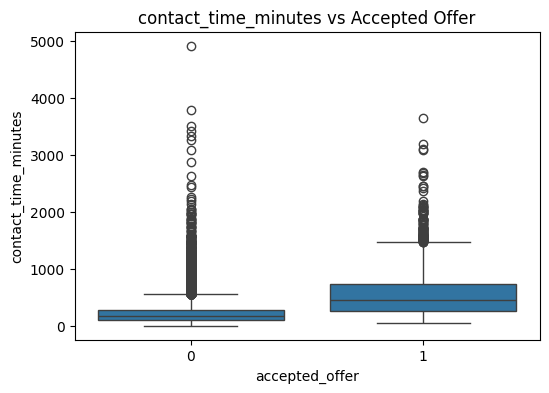

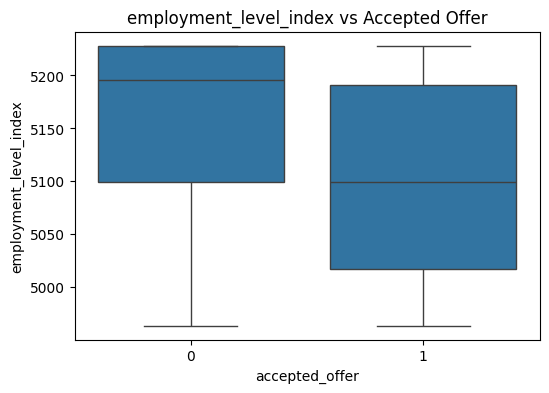

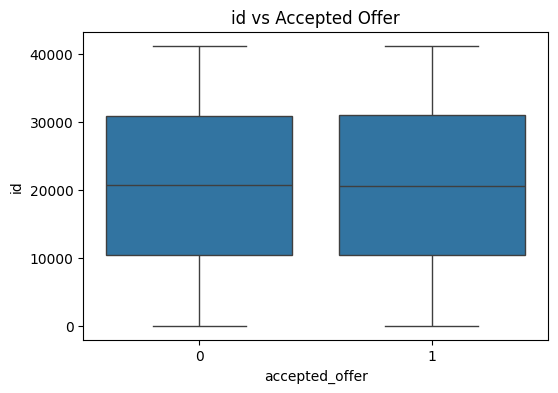

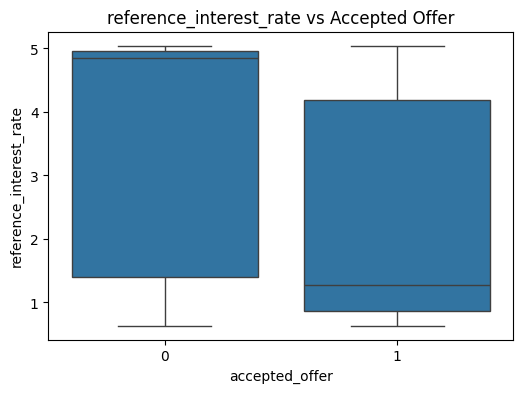

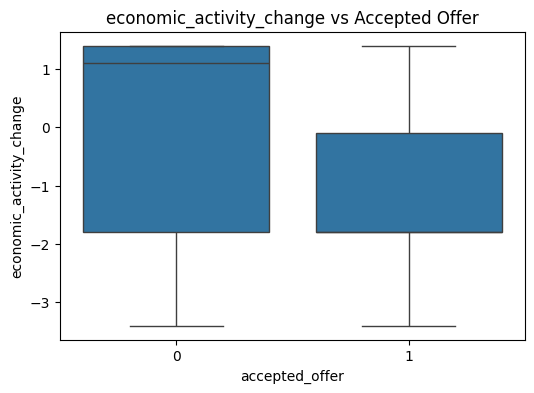

In [15]:
top_num_cols = (
    num_summary_df[
        num_summary_df["median(accepted) - median(declined)"] > 0
    ]
    .sort_values(by="median(accepted) - median(declined)", ascending=False)
    .head(5)["feature"]
    .tolist()
)

print("Numeric features with higher association of accepting offer:", top_num_cols)

for col in top_num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x="accepted_offer", y=col, data=df_train)
    plt.title(f"{col} vs Accepted Offer")
    plt.show()

Checking for correlation

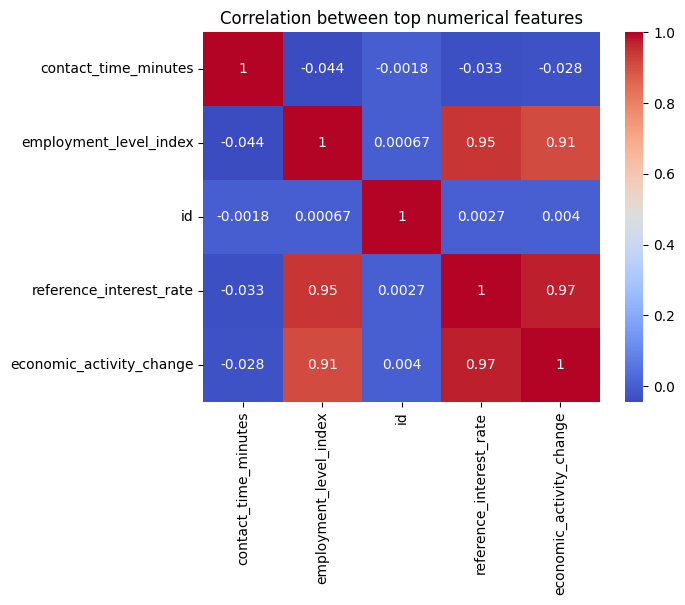

In [16]:
corr = df_train[top_num_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation between top numerical features")
plt.show()

Using library sweetviz to gain a stronger understanding of the dataset

In [ ]:
from IPython.display import IFrame, display

predicting_custresponse = sv.analyze(df_train)
predicting_custresponse.show_html("SWEETVIZ_REPORT.html", open_browser=False)

display(IFrame("SWEETVIZ_REPORT.html", width="100%", height=900)) # render the HTML inside notebook instead of loading HTML in new browser in chrome

checking for skewness

In [18]:
df_train[num_cols].skew().sort_values(ascending=False)

recent_contact_flag          4.868234
contact_attempt_count        4.819243
prior_contact_count          3.820811
contact_time_minutes         3.187435
is_repeat_customer           2.117540
customer_age                 0.790754
consumer_confidence_index    0.305104
id                           0.000965
consumer_price_index        -0.229085
reference_interest_rate     -0.701184
economic_activity_change    -0.716983
employment_level_index      -1.038940
days_since_prior_contact    -4.868351
dtype: float64

The skewness for features contact_attempt_count, prior_contact_count, and contact_time_minutes is very high, but I did not need to transform it for the tree models. However I handled skewness when performing logistic regression.

# Data preparation

In [89]:
# preprocessing for the tree models
numeric_transformer = "passthrough"
categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)


# preprocessing for logistic regression so it can handle skewness better (Yeo-Johnson)
lr_numeric_transformer = PowerTransformer(method="yeo-johnson")

lr_preprocessor = ColumnTransformer(
    transformers=[
        ("num", lr_numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

I can see from the correlation map that 'employment_level_index', 'economic_activity_change', and 'reference_interest_rate' are correlated and are therefore dropped during the data preparation.

In [69]:
X = df_train.drop(['accepted_offer', 'id', 'employment_level_index', 'economic_activity_change'], axis=1)
y = df_train['accepted_offer']

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object']).columns.tolist()

print(cat_cols)
print(num_cols)

['occupation_type', 'relationship_status', 'education_background', 'has_credit_issue', 'mortgage_status', 'personal_loan_status', 'last_contact_month', 'day_of_week', 'prior_outcome_status']
['customer_age', 'contact_time_minutes', 'contact_attempt_count', 'days_since_prior_contact', 'prior_contact_count', 'consumer_price_index', 'consumer_confidence_index', 'reference_interest_rate', 'is_repeat_customer', 'recent_contact_flag', 'contactmin_tocount', 'prior_success_flag', 'prior_failure_flag', 'financial_risk_flag', 'high_engagement', 'high_contact_pressure', 'contact_month_num', 'economic_pressures', 'macro_pressure', 'repeat_success_customer']


C:\Users\prchandr\AppData\Local\Temp\1\ipykernel_22196\2663056679.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object']).columns.tolist()


I re-ran the data preparation code after performing feature engineering to ensure it was applied to the training set 

# Feature Engineering & Feature Selection

In [68]:
# comparing minutes to contact count
df_train["contactmin_tocount"] = (
    df_train["contact_time_minutes"] / df_train["contact_attempt_count"].replace(0, np.nan)
    ).fillna(0)

# converting outcome flags
df_train["prior_success_flag"] = (
    df_train["prior_outcome_status"] == "success"
    ).astype(int)

df_train["prior_failure_flag"] = (
    df_train["prior_outcome_status"] == "failure"
    ).astype(int)

# financial risk feature
df_train["financial_risk_flag"] = (
    (df_train["has_credit_issue"] == "yes") |
    (df_train["personal_loan_status"] == "yes")
    ).astype(int)

# high engagement flag comparing minutes to median
median_contact_time = df_train["contact_time_minutes"].median()
df_train["high_engagement"] = (
    df_train["contact_time_minutes"] > median_contact_time
    ).astype(int)

 # high contact pressure flag
median_attempts = df_train["contact_attempt_count"].median()
df_train["high_contact_pressure"] = (
    df_train["contact_attempt_count"] > median_attempts
    ).astype(int)

# converting months to numbers
month_map = {
    "jan": 1, "feb": 2, "mar": 3, "apr": 4,
    "may": 5, "jun": 6, "jul": 7, "aug": 8,
    "sep": 9, "oct": 10, "nov": 11, "dec": 12
}
df_train["contact_month_num"] = df_train["last_contact_month"].map(month_map)

# consumer view on economic pressures 
df_train["economic_pressures"] = (
    df_train["reference_interest_rate"] - df_train["consumer_confidence_index"]
    )

# economic pressure score
df_train["macro_pressure"] = (
    df_train["reference_interest_rate"] + df_train["consumer_price_index"] - df_train["consumer_confidence_index"]
    )

# Flagging repeat customer with success prior to campaign
df_train["repeat_success_customer"] = (
    (df_train["is_repeat_customer"] == 1) &
    (df_train["prior_outcome_status"] == "success")
    ).astype(int)

I ran all models with the feature engineering set and without the set, and it performed roughly the same. For how much extra time was spent into engineering the features I do not think it was worth it for the slight model improvement. The following models outputs include feature engineering.

I began with a LightGBM as it would be a strong choice for capturing nonlinear relationships and handling mixed categorical and numerical category data.

## LightGBM

In [71]:
X_train, X_val, y_train, y_val = train_test_split(
    X,y, test_size = 0.2, random_state = 42, stratify = y)

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import make_scorer, f1_score, confusion_matrix, classification_report
import numpy as np
from lightgbm import LGBMClassifier

X_test = df_test.drop(
    ['id', 'employment_level_index', 'economic_activity_change'],
    axis=1,
    errors='ignore'
)


# ==============================
# applying cross validation
# ==============================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

f1_scorer = make_scorer(f1_score)


# ==============================
# baseline model evaluation
# ==============================

baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LGBMClassifier(
        objective="binary",
        class_weight="balanced",
        random_state=42,
        verbose=-1
    ))
])

baseline_cv_scores = cross_val_score(
    baseline_model,
    X,
    y,
    cv=cv,
    scoring=f1_scorer
)

print("Baseline CV F1 Scores:", baseline_cv_scores)
print("Baseline Mean CV F1:", baseline_cv_scores.mean())


# ==============================
# cross validated confusion matrix
# ==============================

cv_preds = cross_val_predict(
    baseline_model,
    X,
    y,
    cv=cv
)

print("\nCross-Validated Classification Report:")
print(classification_report(y, cv_preds))

print("\nCross-Validated Confusion Matrix:")
print(confusion_matrix(y, cv_preds))


# ==============================
# Applying parameters
# ==============================

def objective(trial):

    n_rows = X.shape[0]
    n_features = X.shape[1]

    params = {
        "objective": "binary",

        "n_estimators": trial.suggest_int(
            "n_estimators",
            100,
            min(2000, max(300, n_rows // 10))
        ),
        # tests more trees to learn from

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.2
        ),
        # tests whether the model should learn slowly and carefully or faster when patterns are strong

        "num_leaves": trial.suggest_int(
            "num_leaves",
            20,
            min(200, max(31, n_features * 5))
        ),
        # more features → allow more leaves because there are more possible data segments

        "max_depth": trial.suggest_int(
            "max_depth",
            3,
            min(15, max(5, n_features // 2))
        ),
        # more features → allow deeper trees to capture layered relationships

        "min_child_samples": trial.suggest_int(
            "min_child_samples",
            10,
            max(20, int(n_rows * 0.02))
        ),
        # ensures splits are based on enough data; scales with dataset size

        "subsample": trial.suggest_float(
            "subsample",
            0.6,
            1.0
        ),
        # each tree looks at between 60–100% of data to reduce overfitting

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.6,
            1.0
        ),
        # each tree uses 60–100% of features to avoid over-reliance 

        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            0.0,
            5.0
        ),
        # penalizes weak/noisy patterns so the model focuses on stronger signals

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            0.0,
            5.0
        ),
        # smooths predictions so the model doesn’t become overly confident

        "class_weight": "balanced",
        # corrects for class imbalance since there is a very high number of class 0 (no responses) compared to class 1 (responses)

        "random_state": 42,
        "verbose": -1
    }

    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", LGBMClassifier(**params))
    ])

    cv_scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring=f1_scorer
    )

    return cv_scores.mean()


# ==============================
# Applying optuna
# ==============================

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("Best Cross-Validated F1:", study.best_value)
print("Best Params:", study.best_params)


# ==============================
# Final model
# ==============================

final_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LGBMClassifier(
        **study.best_params,
        objective="binary",
        class_weight="balanced",
        random_state=42,
        verbose=-1
    ))
])

final_model.fit(X, y)


# ==============================
# Final confusion matrix
# ==============================

final_cv_preds = cross_val_predict(
    final_model,
    X,
    y,
    cv=cv
)

print("\nFinal Cross-Validated Classification Report:")
print(classification_report(y, final_cv_preds))

print("\nFinal Cross-Validated Confusion Matrix:")
print(confusion_matrix(y, final_cv_preds))

c:\Users\prchandr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\prchandr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\prchandr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\prchandr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\prchandr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\valida

Baseline CV F1 Scores: [0.61299177 0.64348632 0.61911294 0.62389586 0.61744347]
Baseline Mean CV F1: 0.6233860724210738


c:\Users\prchandr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\prchandr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\prchandr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\prchandr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\prchandr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\valida


Cross-Validated Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.87      0.93     29235
           1       0.47      0.91      0.62      3715

    accuracy                           0.88     32950
   macro avg       0.73      0.89      0.77     32950
weighted avg       0.93      0.88      0.89     32950


Cross-Validated Confusion Matrix:
[[25483  3752]
 [  334  3381]]


c:\Users\prchandr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\prchandr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\prchandr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\prchandr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\prchandr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\valida

Best Cross-Validated F1: 0.6460103191985116
Best Params: {'n_estimators': 413, 'learning_rate': 0.05593392324617125, 'num_leaves': 136, 'max_depth': 13, 'min_child_samples': 42, 'subsample': 0.7412743936337155, 'colsample_bytree': 0.9909581386683828, 'reg_alpha': 3.657203575928682, 'reg_lambda': 0.33608885884980577}


c:\Users\prchandr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\prchandr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\prchandr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\prchandr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\prchandr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\valida


Final Cross-Validated Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.90      0.94     29235
           1       0.52      0.86      0.65      3715

    accuracy                           0.89     32950
   macro avg       0.75      0.88      0.79     32950
weighted avg       0.93      0.89      0.90     32950


Final Cross-Validated Confusion Matrix:
[[26288  2947]
 [  537  3178]]


# Logistic Regression

In [ ]:
# I used Yeo-Johnson to handle skewness and scaling for numeric features because logistic regression relies on distance
lr_numeric_transformer = PowerTransformer(method="yeo-johnson")

lr_preprocessor = ColumnTransformer(
    transformers=[
        ("num", lr_numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

logreg_model = Pipeline(steps=[
    ("preprocessor", lr_preprocessor),
    ("classifier", LogisticRegression(
        C=1.0,
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])


# ==============================
# classification report
# ==============================

logreg_cv_proba = cross_val_predict(
    logreg_model,
    X,
    y,
    cv=cv,
    method="predict_proba"
)[:, 1]

logreg_cv_preds = (logreg_cv_proba >= 0.5).astype(int)

print("\nLogistic Regression Classification Report:")
print(classification_report(y, logreg_cv_preds))

print("\nLogistic Regression Confusion Matrix:")
print(confusion_matrix(y, logreg_cv_preds))


Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.86      0.92     29235
           1       0.44      0.89      0.59      3715

    accuracy                           0.86     32950
   macro avg       0.71      0.87      0.75     32950
weighted avg       0.92      0.86      0.88     32950


Logistic Regression Confusion Matrix:
[[25041  4194]
 [  400  3315]]


# Random Forest

In [ ]:
# ==============================
# random forest pipeline
# ==============================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,        # number of trees (more trees = more stable)
        max_depth=None,          # allow trees to grow fully unless data stops them
        min_samples_split=2,     # minimum samples needed to split a node
        min_samples_leaf=1,      # minimum samples in a leaf
        class_weight="balanced", # handle class imbalance
        n_jobs=-1,               # use all CPU cores (important for speed)
        random_state=42
    ))
])


# ==============================
# cross validation
# ==============================

rf_cv_proba = cross_val_predict(
    rf_model,
    X,
    y,
    cv=cv,
    method="predict_proba"
)[:, 1]

rf_cv_preds = (rf_cv_proba >= 0.5).astype(int)

print("\nRandom Forest Classification Report:")
print(classification_report(y, rf_cv_preds))

print("\nRandom Forest Confusion Matrix:")
print(confusion_matrix(y, rf_cv_preds))


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95     29235
           1       0.67      0.47      0.55      3715

    accuracy                           0.91     32950
   macro avg       0.80      0.72      0.75     32950
weighted avg       0.90      0.91      0.91     32950


Random Forest Confusion Matrix:
[[28364   871]
 [ 1977  1738]]


# Extra Trees

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier

# ==============================
# extra trees model pipeline
# ==============================

et_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", ExtraTreesClassifier(
        n_estimators=400,
        max_depth=6,               # shallower → fewer false positives
        min_samples_split=50,      # require strong signal to split
        min_samples_leaf=50,       # large leaves → conservative
        max_features=0.5,          # reduce feature randomness
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=42
    ))
])

et_cv_proba = cross_val_predict(
    et_model,
    X,
    y,
    cv=cv,
    method="predict_proba"
)[:, 1]

et_preds = (et_cv_proba >= 0.5).astype(int)

# ==============================
# extra tree model classification report
# ==============================

print("\nExtra Trees Classification Report:")
print(classification_report(y, et_preds))

print("\nExtra Trees Confusion Matrix:")
print(confusion_matrix(y, et_preds))


Extra Trees Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.81      0.89     29235
           1       0.38      0.92      0.54      3715

    accuracy                           0.82     32950
   macro avg       0.68      0.86      0.71     32950
weighted avg       0.92      0.82      0.85     32950


Extra Trees Confusion Matrix:
[[23613  5622]
 [  293  3422]]


From the models I tested, the lightgbm and random forest were the strongest for ensembling due to different metric strengths in discovering false positives and false negatives.

# Deeper feature engineering before ensembling

Top 25 LightGBM Features:
                                        feature  importance
1                     num__contact_time_minutes       14966
7                  num__reference_interest_rate       10874
0                             num__customer_age       10637
2                    num__contact_attempt_count        2664
5                     num__consumer_price_index        2421
6                num__consumer_confidence_index        2058
3                 num__days_since_prior_contact         576
4                      num__prior_contact_count         530
56                         cat__day_of_week_tue         209
51                  cat__last_contact_month_oct         204
55                         cat__day_of_week_thu         187
54                         cat__day_of_week_mon         151
57                         cat__day_of_week_wed         146
49                  cat__last_contact_month_may         143
32  cat__education_background_university.degree         133
34            

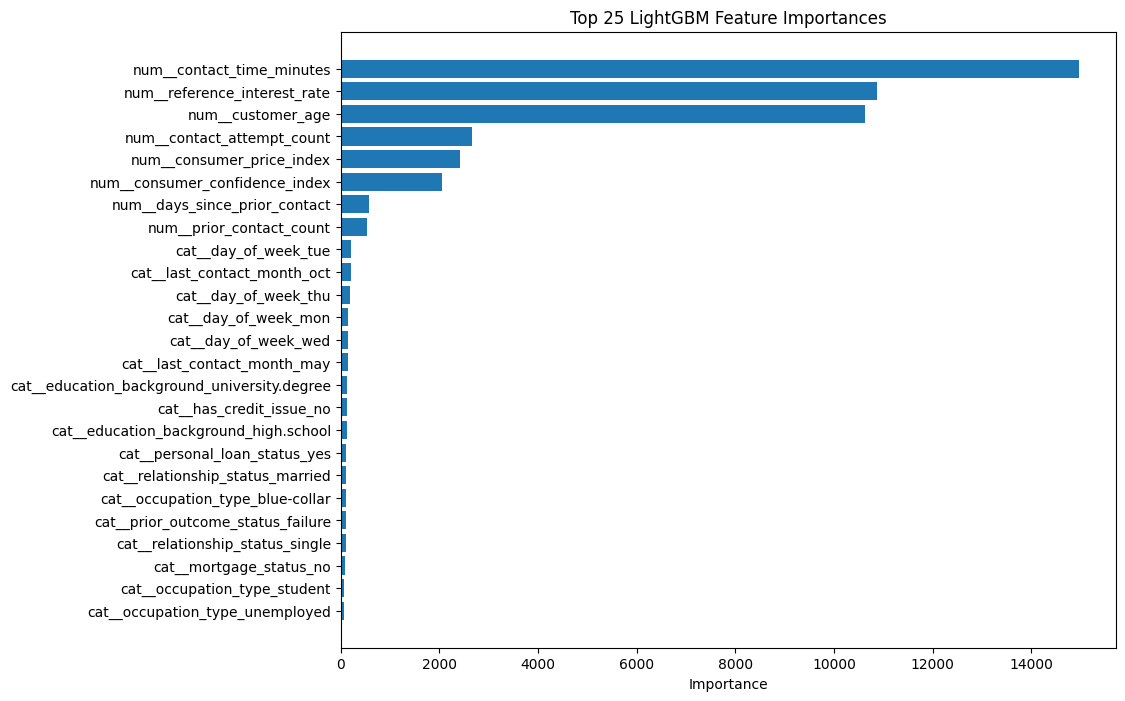

In [ ]:
final_model.fit(X, y)
rf_model.fit(X, y)

# Get transformed feature names after preprocessing
feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()

# ==============================
# Feature importance for best performing model LightGBM
# ==============================

lgbm_importances = final_model.named_steps["classifier"].feature_importances_

lgbm_feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": lgbm_importances
}).sort_values("importance", ascending=False)

print("Top 25 LightGBM Features:")
print(lgbm_feature_importance.head(25))

plt.figure(figsize=(10, 8))
plt.barh(
    lgbm_feature_importance.head(25)["feature"][::-1],
    lgbm_feature_importance.head(25)["importance"][::-1]
)
plt.xlabel("Importance")
plt.title("Top 25 LightGBM Feature Importances")
plt.show()

# Ensembling

In [78]:
ensemble_proba = (0.3 * lgb_oof) + (0.7 * rf_oof)

In [ ]:
# ==============================
# tuning using ensemble weights
# ==============================

thresholds = np.arange(0.1, 0.9, 0.01)

best_threshold = 0
best_f1 = 0

for t in thresholds:
    preds = (ensemble_proba >= t).astype(int)
    score = f1_score(y, preds)

    if score > best_f1:
        best_f1 = score
        best_threshold = t

# ==============================
# ensembling with OOF confusion matrix
# ==============================

ensemble_preds = (ensemble_proba >= best_threshold).astype(int)

print("\nOOF Ensemble Classification Report:")
print(classification_report(y, ensemble_preds))

print("\nOOF Ensemble Confusion Matrix:")
print(confusion_matrix(y, ensemble_preds))


OOF Ensemble Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.92      0.94     29235
           1       0.55      0.80      0.65      3715

    accuracy                           0.90     32950
   macro avg       0.76      0.86      0.80     32950
weighted avg       0.93      0.90      0.91     32950


OOF Ensemble Confusion Matrix:
[[26786  2449]
 [  741  2974]]


# Summarizing Model Performances

In [ ]:
results_summary = pd.DataFrame([
    {
        "Model": "Ensemble (LightGBM + Random Forest)",
        "Preprocessing / Features": "One-hot encoding for categorical features; numeric features retained",
        "Validation Method": "Stratified 5-Fold OOF Cross-Validation + threshold tuning",
        "Accuracy": accuracy_score(y, ensemble_preds),
        "Precision (Class 1)": precision_score(y, ensemble_preds),
        "Recall (Class 1)": recall_score(y, ensemble_preds),
        "F1 Score (Class 1)": f1_score(y, ensemble_preds)
    },
    {
        "Model": "LightGBM",
        "Preprocessing / Features": "One-hot encoding for categorical features; numeric features retained",
        "Validation Method": "Optuna tuning + Stratified 5-Fold Cross-Validation",
        "Accuracy": accuracy_score(y, final_cv_preds),
        "Precision (Class 1)": precision_score(y, final_cv_preds),
        "Recall (Class 1)": recall_score(y, final_cv_preds),
        "F1 Score (Class 1)": f1_score(y, final_cv_preds)
    },
    {
        "Model": "Logistic Regression",
        "Preprocessing / Features": "One-hot encoding for categorical features; numeric features retained",
        "Validation Method": "Stratified 5-Fold Cross-Validation",
        "Accuracy": accuracy_score(y, logreg_cv_preds),
        "Precision (Class 1)": precision_score(y, logreg_cv_preds),
        "Recall (Class 1)": recall_score(y, logreg_cv_preds),
        "F1 Score (Class 1)": f1_score(y, logreg_cv_preds)
    },
    {
        "Model": "Random Forest",
        "Preprocessing / Features": "One-hot encoding for categorical features; numeric features retained",
        "Validation Method": "Stratified 5-Fold Cross-Validation",
        "Accuracy": accuracy_score(y, rf_cv_preds),
        "Precision (Class 1)": precision_score(y, rf_cv_preds),
        "Recall (Class 1)": recall_score(y, rf_cv_preds),
        "F1 Score (Class 1)": f1_score(y, rf_cv_preds)
    },
    {
        "Model": "Extra Trees",
        "Preprocessing / Features": "One-hot encoding for categorical features; numeric features retained",
        "Validation Method": "Stratified 5-Fold Cross-Validation",
        "Accuracy": accuracy_score(y, et_preds),
        "Precision (Class 1)": precision_score(y, et_preds),
        "Recall (Class 1)": recall_score(y, et_preds),
        "F1 Score (Class 1)": f1_score(y, et_preds)
    }
])

results_summary = results_summary.sort_values(
    by=["F1 Score (Class 1)", "Precision (Class 1)", "Recall (Class 1)"],
    ascending=False
).reset_index(drop=True)

results_summary

,Model,Preprocessing / Features,Validation Method,Accuracy,Precision (Class 1),Recall (Class 1),F1 Score (Class 1)
0,Ensemble (LightGBM + Random Forest),One-hot encoding for categorical features; num...,Stratified 5-Fold OOF Cross-Validation + thres...,0.903187,0.548405,0.800538,0.650908
1,LightGBM,One-hot encoding for categorical features; num...,Optuna tuning + Stratified 5-Fold Cross-Valida...,0.894264,0.518857,0.855451,0.645935
2,Logistic Regression,One-hot encoding for categorical features; num...,Stratified 5-Fold Cross-Validation,0.856358,0.432332,0.875370,0.578802
3,Random Forest,One-hot encoding for categorical features; num...,Stratified 5-Fold Cross-Validation,0.913566,0.666156,0.467833,0.549652
4,Extra Trees,One-hot encoding for categorical features; num...,Stratified 5-Fold Cross-Validation,0.820486,0.378372,0.921131,0.536406


Ensembling did improved my model performance and was better than the individual models I tried however it still performed worse than Random Forest, which was surprising to me. I originally thought ensembling would help balance the gap between false positives and false negatives, but Random Forest actually ended up with the lowest number of false positives compared to all other models, including the ensemble model. This matters a lot because if a company is trying to improve customer outreach, they may want a model that predicts responses more accurately by avoiding unnecessary outreach to customers who won’t respond.

I chose the final ensemble model to be with the LightGBM and Random Forest models. LightGBM was stronger at finding true positives (customers who were predicted to respond that actually did), but at the cost of higher false positives. I thought minimizing false positives (predicting customers will respond when they actually did not) was the most important metric for model evaluation because it is more important to correctly identify customers that will not respond to identify stronger marketing tactics and which areas to spend money on. Random Forest had a strength in keeping false positives lower because of its higher precision, but at the cost of missing more true positives. Because these two models had different strengths, I made a weighted soft-voting ensemble and tried different weights until I received the lowest number of false positives that I could. I chose this two-model ensemble as the final model because it kept the false positive count low while still maintaining stronger recall than Random Forest alone. I also tried to add logistic regression however this is did not seem to improve the model as much.

# Final model on test set

In [84]:
# applying the same feature engineering to test set
df_test["contactmin_tocount"] = (
    df_test["contact_time_minutes"] / df_test["contact_attempt_count"].replace(0, np.nan)
).fillna(0)

df_test["prior_success_flag"] = (df_test["prior_outcome_status"] == "success").astype(int)
df_test["prior_failure_flag"] = (df_test["prior_outcome_status"] == "failure").astype(int)

df_test["financial_risk_flag"] = (
    (df_test["has_credit_issue"] == "yes") |
    (df_test["personal_loan_status"] == "yes")
).astype(int)

df_test["high_engagement"] = (df_test["contact_time_minutes"] > median_contact_time).astype(int)
df_test["high_contact_pressure"] = (df_test["contact_attempt_count"] > median_attempts).astype(int)

df_test["contact_month_num"] = df_test["last_contact_month"].map(month_map)

df_test["economic_pressures"] = (
    df_test["reference_interest_rate"] - df_test["consumer_confidence_index"]
)

df_test["macro_pressure"] = (
    df_test["reference_interest_rate"]
    + df_test["consumer_price_index"]
    - df_test["consumer_confidence_index"]
)

df_test["repeat_success_customer"] = (
    (df_test["is_repeat_customer"] == 1) &
    (df_test["prior_outcome_status"] == "success")
).astype(int)

# Data Preparation for the test data
X_test = df_test.drop(['id', 'employment_level_index', 'economic_activity_change'], axis=1, errors='ignore')


# Rebuild preprocessor
categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

In [ ]:
final_lgb = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LGBMClassifier(
        **study.best_params,
        objective="binary",
        class_weight="balanced",
        random_state=42,
        verbose=-1
    ))
])
final_lgb.fit(X, y)

final_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=10,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    ))
])
final_rf.fit(X, y)


lgb_test_proba = final_lgb.predict_proba(X_test)[:, 1]
rf_test_proba = final_rf.predict_proba(X_test)[:, 1]

test_ensemble_proba = (0.3 * lgb_test_proba) + (0.7 * rf_test_proba)
test_predictions = (test_ensemble_proba >= best_threshold).astype(int)

c:\Users\prchandr\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [87]:
chandra_pranika_predictions = pd.DataFrame({
    "id": df_test["id"],
    "accepted_offer": test_predictions
})

chandra_pranika_predictions.to_csv("test_predictions.csv", index=False)

In [88]:
chandra_pranika_predictions.head()

,id,accepted_offer
0,32884,0
1,3169,1
2,32206,1
3,9403,0
4,14020,0
